# Aufgabe 4.2 - GenAI & LLM: Semantisches Clustering

Dieses Notebook erzeugt Embeddings über eine externe OpenAI-kompatible Embeddings-API und clustert SMS nach semantischer Ähnlichkeit. Embeddings werden lokal gecacht, damit spätere Runs nachvollziehbar und günstig bleiben.

In [17]:
from pathlib import Path
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

load_dotenv()

DATA_PATH = Path("data/01_cleaned/sms_cleaned.csv")
CACHE_DIR = Path("data/01_cleaned")
RANDOM_STATE = 42

PRIMARY_EMBEDDING_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")
COMPARE_SMALL_AND_LARGE = True  # Auf False setzen, wenn nur PRIMARY_EMBEDDING_MODEL verwendet werden soll.
SMALL_EMBEDDING_MODEL = "text-embedding-3-small"
LARGE_EMBEDDING_MODEL = "text-embedding-3-large"

EMBEDDING_MODELS = [PRIMARY_EMBEDDING_MODEL]
if COMPARE_SMALL_AND_LARGE:
    EMBEDDING_MODELS = [SMALL_EMBEDDING_MODEL, LARGE_EMBEDDING_MODEL]

EMBEDDING_MODELS = list(dict.fromkeys(EMBEDDING_MODELS))
print(f"Embedding models: {EMBEDDING_MODELS}")

Embedding models: ['text-embedding-3-small', 'text-embedding-3-large']


## Verwendete APIs, Modelle und Bibliotheken

- API/Dienst: OpenAI-kompatible Embeddings-API.
- Primäres Modell: `PRIMARY_EMBEDDING_MODEL`, default `text-embedding-3-small`.
- Optionaler Vergleich: `COMPARE_SMALL_AND_LARGE = True` berechnet und visualisiert `text-embedding-3-small` vs. `text-embedding-3-large`.
- Authentifizierung: `OPENAI_API_KEY` in Environment oder `.env`.
- Optionaler Endpoint: `OPENAI_BASE_URL`, falls ein kompatibler Provider genutzt wird.
- Libraries: `openai`, `python-dotenv`, `pandas`, 
umpy`, `scikit-learn`, `matplotlib`, `seaborn`.

Warum Embeddings: Bag-of-Words erkennt Wortüberschneidungen, aber keine semantische Nähe. Embeddings bilden komplette SMS als dichte Vektoren ab, wodurch ähnliche Absichten und Themen auch bei anderer Wortwahl näher zusammenliegen.

In [18]:
df = pd.read_csv(DATA_PATH, encoding="utf-8")
display(df.head())
display(df["label"].value_counts().to_frame("count"))

,label,target,message
0,ham,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives around here though"


,count
label,
ham,4516
spam,642


## Embeddings erzeugen oder aus Cache laden

Der Cache ist bewusst Teil von `data/01_cleaned`, weil er aus dem bereinigten Datensatz abgeleitet ist. Wenn das Modell gewechselt wird, entsteht automatisch ein separater Cache-Dateiname.

In [19]:
def embedding_cache_path(model):
    safe_model_name = model.replace("/", "_").replace(":", "_")
    return CACHE_DIR / f"sms_embeddings_{safe_model_name}.npy"


def embed_texts(texts, model, batch_size=128, sleep_seconds=0.0):
    client_kwargs = {"api_key": os.getenv("OPENAI_API_KEY")}
    if os.getenv("OPENAI_BASE_URL"):
        client_kwargs["base_url"] = os.getenv("OPENAI_BASE_URL")
    client = OpenAI(**client_kwargs)
    vectors = []
    for start in range(0, len(texts), batch_size):
        batch = texts[start : start + batch_size]
        response = client.embeddings.create(model=model, input=batch)
        vectors.extend([item.embedding for item in response.data])
        print(f"{model}: embedded {min(start + batch_size, len(texts))}/{len(texts)}")
        if sleep_seconds:
            time.sleep(sleep_seconds)
    return np.asarray(vectors, dtype=np.float32)


def load_or_create_embeddings(model):
    cache_path = embedding_cache_path(model)
    if cache_path.exists():
        vectors = np.load(cache_path)
        print(f"Loaded cached embeddings: {cache_path} {vectors.shape}")
    else:
        if not os.getenv("OPENAI_API_KEY"):
            raise RuntimeError("OPENAI_API_KEY ist nicht gesetzt. Bitte .env anlegen oder Environment Variable setzen.")
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        vectors = embed_texts(df["message"].tolist(), model=model)
        np.save(cache_path, vectors)
        print(f"Saved embeddings: {cache_path} {vectors.shape}")

    if vectors.shape[0] == len(df):
        print(f"{model}: embedding rows match dataset rows: {vectors.shape[0]}")
    else:
        print(f"WARNING: {model}: embedding count {vectors.shape[0]} does not match row count {len(df)}")
    return vectors

embeddings_by_model = {model: load_or_create_embeddings(model) for model in EMBEDDING_MODELS}

EMBEDDING_MODEL = EMBEDDING_MODELS[0]
embeddings = embeddings_by_model[EMBEDDING_MODEL]
print(f"Primary model for detailed analysis: {EMBEDDING_MODEL}")

Loaded cached embeddings: data\01_cleaned\sms_embeddings_text-embedding-3-small.npy (5158, 1536)
text-embedding-3-small: embedding rows match dataset rows: 5158
text-embedding-3-large: embedded 128/5158
text-embedding-3-large: embedded 256/5158
text-embedding-3-large: embedded 384/5158
text-embedding-3-large: embedded 512/5158
text-embedding-3-large: embedded 640/5158
text-embedding-3-large: embedded 768/5158
text-embedding-3-large: embedded 896/5158
text-embedding-3-large: embedded 1024/5158
text-embedding-3-large: embedded 1152/5158
text-embedding-3-large: embedded 1280/5158
text-embedding-3-large: embedded 1408/5158
text-embedding-3-large: embedded 1536/5158
text-embedding-3-large: embedded 1664/5158
text-embedding-3-large: embedded 1792/5158
text-embedding-3-large: embedded 1920/5158
text-embedding-3-large: embedded 2048/5158
text-embedding-3-large: embedded 2176/5158
text-embedding-3-large: embedded 2304/5158
text-embedding-3-large: embedded 2432/5158
text-embedding-3-large: embed

Embeddings werden L2-normalisiert, damit KMeans stärker auf Richtung/semantische Ähnlichkeit und weniger auf Vektorlänge reagiert.
L2 Normalisierung deswegen, weil KMeans mit euklidischer Distanz arbeitet, ohne Normalisierung misst K-Means nicht nur Richtung der Embeddings, sondern auch dessen Länge. Bei Text Embeddings ist aber meistens die Richtung wichtiger als die Länge.

,embedding_model,k,silhouette,inertia
0,text-embedding-3-small,2,0.0309,4029.4851
1,text-embedding-3-small,3,0.0249,3962.0610
2,text-embedding-3-small,4,0.0254,3913.7744
3,text-embedding-3-small,5,0.0241,3878.5244
4,text-embedding-3-small,6,0.0229,3846.3486
5,text-embedding-3-small,7,0.0221,3822.2095
6,text-embedding-3-small,8,0.0205,3799.1904
7,text-embedding-3-small,9,0.0137,3776.8311
8,text-embedding-3-small,10,0.0148,3759.0208
9,text-embedding-3-small,11,0.0152,3743.1609


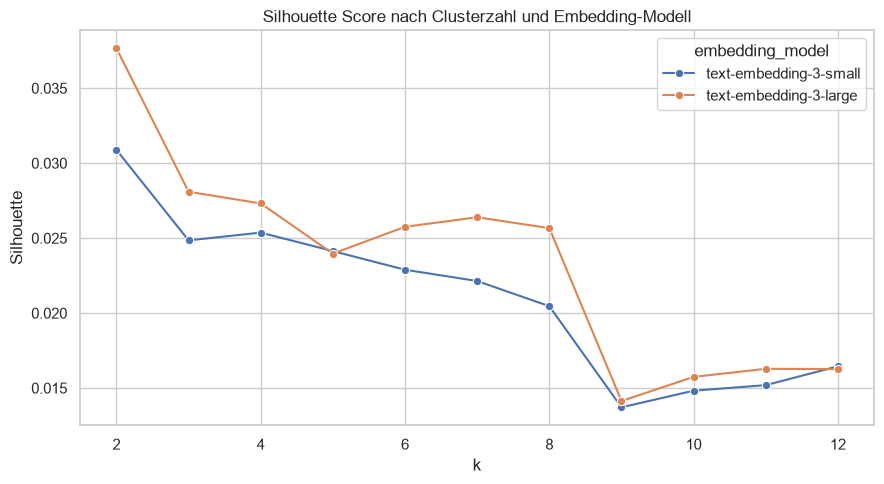

In [20]:
def score_kmeans_for_embeddings(vectors, model_name, k_values=range(2, 13)):
    X_model = normalize(vectors)
    rows = []
    fitted = {}
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X_model)
        score = silhouette_score(X_model, labels, metric="euclidean")
        rows.append({"embedding_model": model_name, "k": k, "silhouette": score, "inertia": model.inertia_})
        fitted[k] = {"model": model, "labels": labels, "X": X_model}
    return pd.DataFrame(rows), fitted

score_tables = []
fitted_by_embedding_model = {}
for model_name, vectors in embeddings_by_model.items():
    model_scores, fitted = score_kmeans_for_embeddings(vectors, model_name)
    score_tables.append(model_scores)
    fitted_by_embedding_model[model_name] = fitted

scores_all_df = pd.concat(score_tables, ignore_index=True)
display(scores_all_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=scores_all_df, x="k", y="silhouette", hue="embedding_model", marker="o", ax=ax)
ax.set_title("Silhouette Score nach Clusterzahl und Embedding-Modell")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette")
plt.tight_layout()

scores_df = scores_all_df[scores_all_df["embedding_model"] == EMBEDDING_MODEL].copy()
X = fitted_by_embedding_model[EMBEDDING_MODEL][int(scores_df.sort_values("silhouette", ascending=False).iloc[0]["k"])] ["X"]

In [21]:
best_rows = scores_all_df.loc[scores_all_df.groupby("embedding_model")["silhouette"].idxmax()].copy()
best_rows = best_rows.sort_values("silhouette", ascending=False).reset_index(drop=True)
display(best_rows.round(4))

best_k = int(best_rows.loc[best_rows["embedding_model"] == EMBEDDING_MODEL, "k"].iloc[0])
print(f"Gewählte Clusterzahl für {EMBEDDING_MODEL}: k={best_k}")

cluster_model = fitted_by_embedding_model[EMBEDDING_MODEL][best_k]["model"]
X = fitted_by_embedding_model[EMBEDDING_MODEL][best_k]["X"]
df_clustered = df.copy()
df_clustered["cluster"] = fitted_by_embedding_model[EMBEDDING_MODEL][best_k]["labels"]

cluster_summary = pd.crosstab(df_clustered["cluster"], df_clustered["label"], margins=True)
display(cluster_summary)

,embedding_model,k,silhouette,inertia
0,text-embedding-3-large,2,0.0377,4118.5542
1,text-embedding-3-small,2,0.0309,4029.4851


Gewählte Clusterzahl für text-embedding-3-small: k=2


label,ham,spam,All
cluster,,,
0,51,613,664
1,4465,29,4494
All,4516,642,5158


## Vergleich: Small vs. Large Embeddings

Wenn `COMPARE_SMALL_AND_LARGE = True` ist, vergleicht diese Sektion die beste Silhouette, die gewählte Clusterzahl, die Label-Verteilung pro Cluster und die PCA-Projektionen der Embedding-Räume.

## K-Means Metriken

### Inertia

Die Inertia misst die Summe der quadrierten Abstände aller Punkte zu ihrem jeweiligen Clusterzentrum:

$$
\text{Inertia} = \sum_{i=1}^{n} \left\| x_i - \mu_{c_i} \right\|^2
$$

Dabei ist:

$$
x_i = \text{Datenpunkt}
$$

$$
\mu_{c_i} = \text{Zentrum des Clusters, dem } x_i \text{ zugeordnet ist}
$$

Eine niedrigere Inertia bedeutet kompaktere Cluster.

---

### Silhouette Score

Für jeden Punkt wird verglichen, wie gut er zum eigenen Cluster passt und wie weit er vom nächsten fremden Cluster entfernt ist.

$$
a(i) = \text{durchschnittliche Distanz von } x_i \text{ zu allen Punkten im eigenen Cluster}
$$

$$
b(i) = \text{durchschnittliche Distanz von } x_i \text{ zum nächstgelegenen anderen Cluster}
$$

Der Silhouette-Wert eines Punktes ist:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Der gesamte Silhouette Score ist der Durchschnitt über alle Punkte:

$$
S = \frac{1}{n} \sum_{i=1}^{n} s(i)
$$

Interpretation:

| Score | Bedeutung |
|---:|---|
| nahe 1 | gut getrennte Cluster |
| nahe 0 | überlappende Cluster |
| negativ | Punkt vermutlich falsch zugeordnet |



Wir verwenden Silhouette als Metrik, da Inertia meist immer zu mehr K zieht und das bei diesem Beispiel nicht sehr viel Sinn macht, da wir ja wissen, dass es 2 Klassen gibt.


,embedding_model,best_k,best_silhouette,embedding_dim
1,text-embedding-3-large,2,0.0377,3072
0,text-embedding-3-small,2,0.0309,1536


Adjusted Rand Index zwischen text-embedding-3-small und text-embedding-3-large: 0.9495


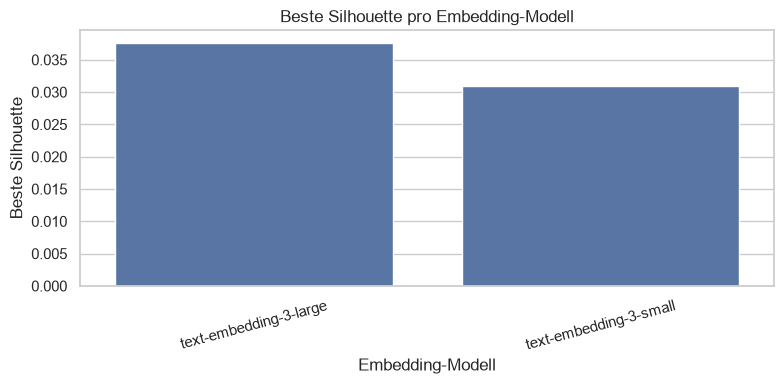

In [27]:
if len(EMBEDDING_MODELS) > 1:
    comparison_rows = []
    label_distribution_tables = {}
    best_labels_by_model = {}

    for model_name in EMBEDDING_MODELS:
        best_row = best_rows[best_rows["embedding_model"] == model_name].iloc[0]
        model_best_k = int(best_row["k"])
        labels = fitted_by_embedding_model[model_name][model_best_k]["labels"]
        best_labels_by_model[model_name] = labels
        clustered_tmp = df.assign(cluster=labels)
        label_table = pd.crosstab(clustered_tmp["cluster"], clustered_tmp["label"], normalize="index").fillna(0)
        label_distribution_tables[model_name] = label_table
        comparison_rows.append({
            "embedding_model": model_name,
            "best_k": model_best_k,
            "best_silhouette": best_row["silhouette"],
            "embedding_dim": embeddings_by_model[model_name].shape[1],
        })

    embedding_comparison_df = pd.DataFrame(comparison_rows).sort_values("best_silhouette", ascending=False)
    display(embedding_comparison_df.round(4))

    if len(best_labels_by_model) == 2:
        left_name, right_name = EMBEDDING_MODELS
        ari = adjusted_rand_score(best_labels_by_model[left_name], best_labels_by_model[right_name])
        print(f"Adjusted Rand Index zwischen {left_name} und {right_name}: {ari:.4f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=embedding_comparison_df, x="embedding_model", y="best_silhouette", ax=ax)
    ax.set_title("Beste Silhouette pro Embedding-Modell")
    ax.set_xlabel("Embedding-Modell")
    ax.set_ylabel("Beste Silhouette")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
else:
    print("Small-vs-Large-Vergleich deaktiviert. Setze COMPARE_SMALL_AND_LARGE = True im ersten Codefeld.")

Label-Verteilung pro Cluster: text-embedding-3-small


label,ham,spam
cluster,,
0,0.077,0.923
1,0.994,0.006


Label-Verteilung pro Cluster: text-embedding-3-large


label,ham,spam
cluster,,
0,0.027,0.973
1,0.993,0.007


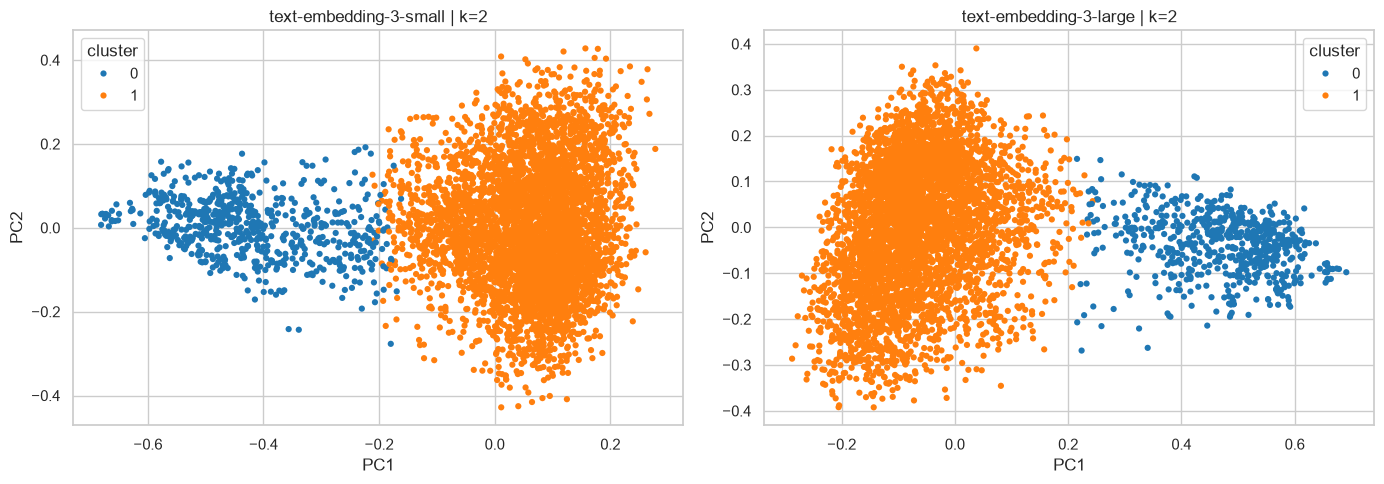

In [28]:
if len(EMBEDDING_MODELS) > 1:
    fig, axes = plt.subplots(1, len(EMBEDDING_MODELS), figsize=(7 * len(EMBEDDING_MODELS), 5), squeeze=False)
    for ax, model_name in zip(axes.ravel(), EMBEDDING_MODELS):
        best_k_for_model = int(best_rows.loc[best_rows["embedding_model"] == model_name, "k"].iloc[0])
        X_model = fitted_by_embedding_model[model_name][best_k_for_model]["X"]
        labels = fitted_by_embedding_model[model_name][best_k_for_model]["labels"]
        projection_model = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
        plot_tmp = df.assign(cluster=labels, x=projection_model[:, 0], y=projection_model[:, 1])
        sns.scatterplot(data=plot_tmp, x="x", y="y", hue="cluster", palette="tab10", s=20, linewidth=0, ax=ax)
        ax.set_title(f"{model_name} | k={best_k_for_model}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
    plt.tight_layout()

    for model_name, label_table in label_distribution_tables.items():
        print(f"Label-Verteilung pro Cluster: {model_name}")
        display(label_table.round(3))

## Cluster interpretieren

Zur Interpretation werden pro Cluster die nächsten SMS zum Clusterzentrum und häufige Begriffe angezeigt. Das ist wichtig, weil Clustering unüberwacht ist und Cluster keine automatischen Namen haben.

In [24]:
distances = euclidean_distances(X, cluster_model.cluster_centers_)

representatives = []
for cluster_id in sorted(df_clustered["cluster"].unique()):
    idx = np.where(df_clustered["cluster"].to_numpy() == cluster_id)[0]
    nearest = idx[np.argsort(distances[idx, cluster_id])[:5]]
    representatives.append(df_clustered.iloc[nearest][["cluster", "label", "message"]])

display(pd.concat(representatives).reset_index(drop=True))

,cluster,label,message
0,0,spam,"URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ASAP! BOX97N7QP, 150ppm"
1,0,spam,"URGENT! Your mobile No 077xxx WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362206 ASAP! BOX97N7QP, 150ppm"
2,0,spam,"URGENT! Your mobile was awarded a £1,500 Bonus Caller Prize on 27/6/03. Our final attempt 2 contact U! Call 08714714011"
3,0,spam,"URGENT! Your mobile No 07xxxxxxxxx won a £2,000 bonus caller prize on 02/06/03! this is the 2nd attempt to reach YOU! call 09066362231 ASAP! BOX97N7QP, 150PPM"
4,0,spam,URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09061790121 from land line. Claim 3030. Valid 12hrs only 150ppm
5,1,ham,U can call me now...
6,1,ham,Ok i msg u b4 i leave my house.
7,1,ham,I tot it's my group mate... Lucky i havent reply... Wat time do ü need to leave...
8,1,ham,Ok i thk i got it. Then u wan me 2 come now or wat?
9,1,ham,K sure am in my relatives home. Sms me de. Pls:-)


In [25]:
def top_cluster_terms(messages, top_n=12):
    vectorizer = CountVectorizer(stop_words="english", lowercase=True, token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z']+\b", min_df=2)
    matrix = vectorizer.fit_transform(messages)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    return ", ".join(pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False).head(top_n)["term"])

term_summary = (
    df_clustered.groupby("cluster")
    .agg(size=("message", "size"), spam_share=("target", "mean"), top_terms=("message", top_cluster_terms))
    .reset_index()
)
term_summary["spam_share"] = term_summary["spam_share"].round(3)
display(term_summary)

,cluster,size,spam_share,top_terms
0,0,664,0.923,"free, txt, ur, mobile, stop, text, claim, reply, www, prize, just, cash"
1,1,4494,0.006,"i'm, just, ok, got, know, like, good, come, ur, time, love, day"


## 2D-Visualisierung

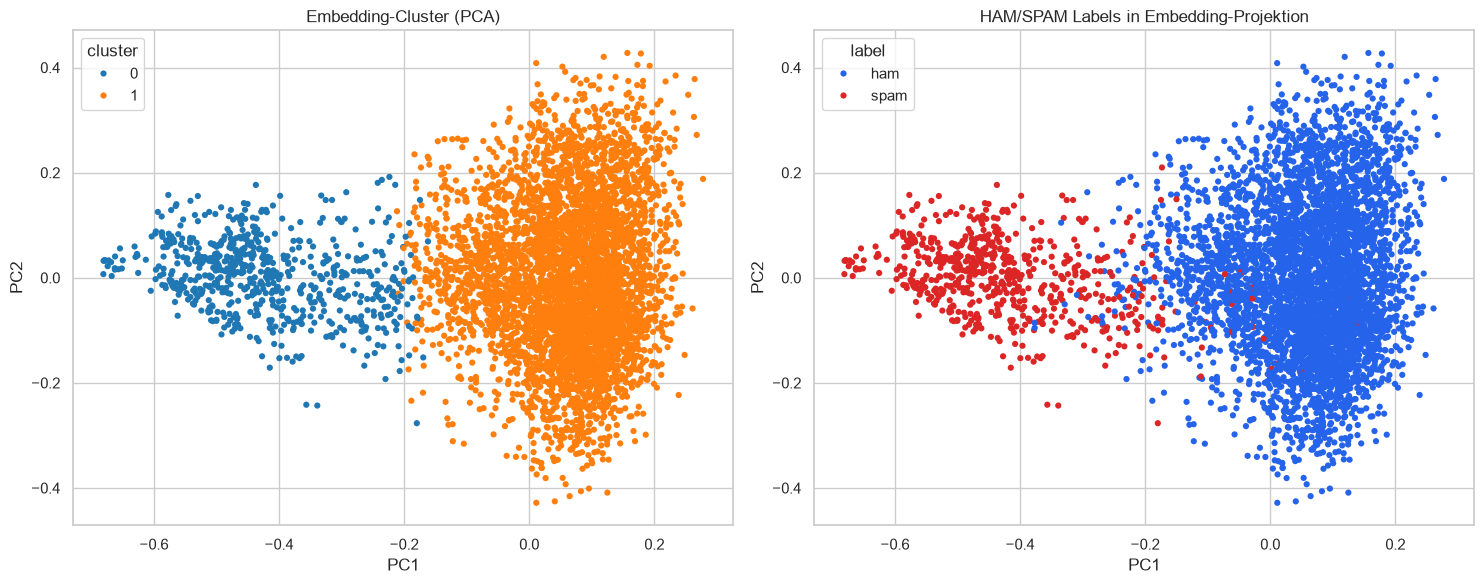

In [26]:
projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
plot_df = df_clustered.assign(x=projection[:, 0], y=projection[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_df, x="x", y="y", hue="cluster", palette="tab10", s=20, linewidth=0, ax=axes[0])
axes[0].set_title("Embedding-Cluster (PCA)")
sns.scatterplot(data=plot_df, x="x", y="y", hue="label", palette={"ham": "#2563eb", "spam": "#dc2626"}, s=20, linewidth=0, ax=axes[1])
axes[1].set_title("HAM/SPAM Labels in Embedding-Projektion")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()

## Beispiele aus der Clusterung

Die folgenden Tabellen zeigen konkrete SMS-Beispiele anhand der Cluster-Mehrheit:

- eindeutige HAM-Beispiele: tatsächliches Label `ham` in einem überwiegend HAM-Cluster
- eindeutige SPAM-Beispiele: tatsächliches Label `spam` in einem überwiegend SPAM-Cluster
- SPAM im HAM-Cluster: tatsächliches Label `spam`, aber Cluster-Mehrheit ist `ham`
- HAM im SPAM-Cluster: tatsächliches Label `ham`, aber Cluster-Mehrheit ist `spam`

Die Beispiele werden pro Kategorie möglichst nah am jeweiligen Clusterzentrum gewählt. Dadurch sind sie repräsentativ für den Bereich, in dem sie liegen.

In [29]:
cluster_label_counts = pd.crosstab(df_clustered["cluster"], df_clustered["label"])
cluster_label_shares = cluster_label_counts.div(cluster_label_counts.sum(axis=1), axis=0)
cluster_majority = cluster_label_shares.idxmax(axis=1).rename("cluster_majority_label")
cluster_majority_share = cluster_label_shares.max(axis=1).rename("cluster_majority_share")

example_df = df_clustered.copy()
example_df["cluster_majority_label"] = example_df["cluster"].map(cluster_majority)
example_df["cluster_majority_share"] = example_df["cluster"].map(cluster_majority_share)
example_df["distance_to_cluster_center"] = distances[np.arange(len(example_df)), example_df["cluster"].to_numpy()]

summary_for_examples = pd.concat([cluster_label_counts, cluster_label_shares.add_suffix("_share")], axis=1).reset_index()
display(summary_for_examples.round(3))


def show_examples(title, condition, n=3):
    cols = [
        "cluster",
        "cluster_majority_label",
        "cluster_majority_share",
        "label",
        "distance_to_cluster_center",
        "message",
    ]
    subset = (
        example_df.loc[condition, cols]
        .sort_values(["cluster_majority_share", "distance_to_cluster_center"], ascending=[False, True])
        .head(n)
        .reset_index(drop=True)
    )
    print(title)
    if subset.empty:
        print("Keine Beispiele für diese Kategorie gefunden.")
    else:
        display(subset)

show_examples(
    "Eindeutige HAM-Beispiele: HAM in überwiegend HAM-Cluster",
    (example_df["label"] == "ham") & (example_df["cluster_majority_label"] == "ham"),
)
show_examples(
    "Eindeutige SPAM-Beispiele: SPAM in überwiegend SPAM-Cluster",
    (example_df["label"] == "spam") & (example_df["cluster_majority_label"] == "spam"),
)
show_examples(
    "SPAM im HAM-Cluster: semantisch bei HAM-nahen Nachrichten, aber Label ist SPAM",
    (example_df["label"] == "spam") & (example_df["cluster_majority_label"] == "ham"),
)
show_examples(
    "HAM im SPAM-Cluster: semantisch bei SPAM-nahen Nachrichten, aber Label ist HAM",
    (example_df["label"] == "ham") & (example_df["cluster_majority_label"] == "spam"),
)

label,cluster,ham,spam,ham_share,spam_share
0,0,51,613,0.077,0.923
1,1,4465,29,0.994,0.006


Eindeutige HAM-Beispiele: HAM in überwiegend HAM-Cluster


,cluster,cluster_majority_label,cluster_majority_share,label,distance_to_cluster_center,message
0,1,ham,0.993547,ham,0.803901,U can call me now...
1,1,ham,0.993547,ham,0.804262,Ok i msg u b4 i leave my house.
2,1,ham,0.993547,ham,0.806168,I tot it's my group mate... Lucky i havent reply... Wat time do ü need to leave...


Eindeutige SPAM-Beispiele: SPAM in überwiegend SPAM-Cluster


,cluster,cluster_majority_label,cluster_majority_share,label,distance_to_cluster_center,message
0,0,spam,0.923193,spam,0.610099,"URGENT! Your mobile No *********** WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362220 ASAP! BOX97N7QP, 150ppm"
1,0,spam,0.923193,spam,0.611819,"URGENT! Your mobile No 077xxx WON a £2,000 Bonus Caller Prize on 02/06/03! This is the 2nd attempt to reach YOU! Call 09066362206 ASAP! BOX97N7QP, 150ppm"
2,0,spam,0.923193,spam,0.614678,"URGENT! Your mobile was awarded a £1,500 Bonus Caller Prize on 27/6/03. Our final attempt 2 contact U! Call 08714714011"


SPAM im HAM-Cluster: semantisch bei HAM-nahen Nachrichten, aber Label ist SPAM


,cluster,cluster_majority_label,cluster_majority_share,label,distance_to_cluster_center,message
0,1,ham,0.993547,spam,0.852221,"Hi babe its Chloe, how r u? I was smashed on saturday night, it was great! How was your weekend? U been missing me? SP visionsms.com Text stop to stop 150p/..."
1,1,ham,0.993547,spam,0.857165,Sorry I missed your call let's talk when you have the time. I'm on 07090201529
2,1,ham,0.993547,spam,0.875215,Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we go slo n hard! Txt XXX SLO(4msgs)


HAM im SPAM-Cluster: semantisch bei SPAM-nahen Nachrichten, aber Label ist HAM


,cluster,cluster_majority_label,cluster_majority_share,label,distance_to_cluster_center,message
0,0,spam,0.923193,ham,0.808891,U can call now...
1,0,spam,0.923193,ham,0.812314,MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
2,0,spam,0.923193,ham,0.815123,"Hi, Mobile no. <#> has added you in their contact list on www.fullonsms.com It s a great place to send free sms to people For more visit fullonsms.com"
